# Functions to parse and clean data

### Imports

In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Parse data

In [3]:
# PARSING 
def parse_custom_csv(path):
    with open(path, "r") as f:
        lines = f.readlines()

    sections = {"META": [], "EVENTS": [], "METER": []}
    current = None

    for line in lines:
        line = line.strip()

        if line.startswith("#"):
            current = line.replace("#", "").strip() #define current section as the header
            continue

        if current and line:  # <-- FIX: skip empty lines
            sections[current].append(line)

    # META
    meta = {}
    for row in sections["META"]:
        k, v = row.split(",", 1)
        meta[k] = v

   # EVENTS
    header = sections["EVENTS"][0].split(",")
    data = [r.split(",") for r in sections["EVENTS"][1:]]
    events = pd.DataFrame(data, columns=header)
    

    # METER
    clean_rows = []
    header = sections["METER"][0].split(",")
    for line in sections["METER"][1:]:
        parts = line.split(",")
        # Only keep valid rows with exactly 3 columns
        if len(parts) != 3:
            continue
        clean_rows.append(parts)
    meter = pd.DataFrame(clean_rows, columns=["timestamp", "v_shunt", "phase"])
    

    return meta, events, meter

## Clean data

In [4]:
# CLEANING
def clean_data(meta, meter, run_id):

    meter["timestamp"] = pd.to_datetime(meter["timestamp"])
    meter["v_shunt"] = meter["v_shunt"].astype(float)

    # Add run id
    meter["run"] = run_id

    # Add payload size
    meter["payload_size"] = 0
    # TX rows
    tx_mask = meter["phase"].astype(str).str.startswith("tx_")
    meter.loc[tx_mask, "payload_size"] = (
        meter.loc[tx_mask, "phase"]
        .str.replace("tx_", "")
        .astype(int)
    )
    return meta, meter

## Align timings and label phases
So that time is standard over all runs

In [7]:
def align_time(meter):
    # Find first non-baseline timestamp
    non_baseline = meter[meter["phase"] != "baseline"]

    if len(non_baseline) == 0:
        raise ValueError("No non-baseline data found")

    t0 = non_baseline["timestamp"].iloc[0]

    # Create relative time
    meter["t_s"] = (meter["timestamp"] - t0).dt.total_seconds()

    return meter

## Test the functions

In [9]:
file1 = Path("/Users/jude/Documents/GitHub/BTR/experiments/WiFi/experiment 1 (all in one)/data/esp32/full_payload/proper run/esp32_full_payload_run01.csv")
meta1, events1, meter1 = parse_custom_csv(file1)
meta1, meter1 = clean_data(meta1, meter1, run_id=1)
meter1 = align_time(meter1)
print(events1.head())
print(meter1.head())


Empty DataFrame
Columns: [run, payload_size, declared_size, bytes_received, tx_start, rx_end, complete, verified, skip_reason]
Index: []
                timestamp   v_shunt     phase  run  payload_size    t_s
0 2026-03-26 20:30:58.078  115.0735  baseline    1             0 -5.007
1 2026-03-26 20:30:58.088  115.0735  baseline    1             0 -4.997
2 2026-03-26 20:30:58.091  107.8088  baseline    1             0 -4.994
3 2026-03-26 20:30:58.094  107.8088  baseline    1             0 -4.991
4 2026-03-26 20:30:58.097  107.8088  baseline    1             0 -4.988


Run on all files

In [10]:
all_meter = []
all_events = []

data_dir = Path("/Users/jude/Documents/GitHub/BTR/experiments/WiFi/experiment 1 (all in one)/data/esp32/full_payload/proper run")

for i, file in enumerate(sorted(data_dir.glob("*.csv"))):
    meta, events, meter = parse_custom_csv(file)
    meta, meter = clean_data(meta, meter, run_id=i+1)
    meter = align_time(meter)

    all_meter.append(meter)
    all_events.append(events)

meter_df = pd.concat(all_meter, ignore_index=True)
events_df = pd.concat(all_events, ignore_index=True)

In [11]:
print(meter_df)

                     timestamp   v_shunt     phase  run  payload_size     t_s
0      2026-03-26 20:30:58.078  115.0735  baseline    1             0  -5.007
1      2026-03-26 20:30:58.088  115.0735  baseline    1             0  -4.997
2      2026-03-26 20:30:58.091  107.8088  baseline    1             0  -4.994
3      2026-03-26 20:30:58.094  107.8088  baseline    1             0  -4.991
4      2026-03-26 20:30:58.097  107.8088  baseline    1             0  -4.988
...                        ...       ...       ...  ...           ...     ...
636146 2026-03-26 21:10:56.621  107.9484      idle   30             0  32.586
636147 2026-03-26 21:10:56.624  107.9484      idle   30             0  32.589
636148 2026-03-26 21:10:56.628  107.9484      idle   30             0  32.593
636149 2026-03-26 21:10:56.631  107.9484      idle   30             0  32.596
636150 2026-03-26 21:10:56.634  107.9484      idle   30             0  32.599

[636151 rows x 6 columns]


# Stats and plots 

Ok so i want

For **each seperate run**: mean power during transmissons, std (within run variation) and count, time spent in transmission state 
- tx 1 : avg v_shunt, std of v_shunt, count of measurements, Time 
- etc.

For **all runs**: Mean power of all ?byte transmission, std (between run variation) (count is 30), avg time spent in tx of payload, std and count ?


In [12]:
voltage_df = meter_df.copy()

### Power
Power: 
P = V_supply * I

Current: 
I = V_shunt/R

In [13]:
R = 1.131667        # ohms
V_supply = 5.013517 # volts

meter_df["current_A"] = meter_df["v_shunt"] / R
meter_df["power_W"] = V_supply * meter_df["current_A"]

print(meter_df[["current_A","power_W"]])

         current_A     power_W
0       101.684948  509.799215
1       101.684948  509.799215
2        95.265480  477.615104
3        95.265480  477.615104
4        95.265480  477.615104
...            ...         ...
636146   95.388838  478.233560
636147   95.388838  478.233560
636148   95.388838  478.233560
636149   95.388838  478.233560
636150   95.388838  478.233560

[636151 rows x 2 columns]


In [14]:
# Uncertainties
#power_uncertainty = delta_Vsupply / V_supply + delta_Vshunt / v_shunt + delta_R / R

R_unc = 0.05 * R  # 5%
V_supply_unc = 0.01 * V_supply  # example, depends on meter
V_shunt_unc = 0.001  # approximation bcs its percent of value + 2tomes last digit (9 0's after decimal in our case)

meter_df["power_unc"] = meter_df["power_W"] * np.sqrt(
    (V_supply_unc / V_supply)**2 +
    (V_shunt_unc / meter_df["v_shunt"])**2 +
    (R_unc / R)**2
)

In [15]:
print(meter_df.columns)

Index(['timestamp', 'v_shunt', 'phase', 'run', 'payload_size', 't_s',
       'current_A', 'power_W', 'power_unc'],
      dtype='object')


### Per run

In [17]:
nonbaseline_df = meter_df[meter_df["phase"] != "baseline"]

per_run_stats = (
    nonbaseline_df
    .groupby(["run", "payload_size"])
    .agg(
        mean_v_shunt=("v_shunt", "mean"),
        std_v_shunt=("v_shunt", "std"),
        
        mean_power=("power_W", "mean"),
        std_power=("power_W", "std"),
        count=("power_W", "count"),
        duration_s=("t_s", lambda x: x.max() - x.min()),

        # measurement uncertainty propagation
        mean_power_unc=("power_unc", lambda x: np.sqrt((x**2).sum()) / len(x))
    ) 
    .assign(
        se_power=lambda df: df["std_power"] / np.sqrt(df["count"])
    )
    .reset_index()
)

baseline_stats = (
    meter_df[meter_df["phase"] == "baseline"]
    .groupby("run")
    .agg(
        baseline_mean_v_shunt=("v_shunt", "mean"),
        baseline_std_v_shunt=("v_shunt", "std"),

        baseline_mean_power=("power_W", "mean"),
        baseline_std_power=("power_W", "std"),
        baseline_count=("power_W", "count"),
        mean_baseline_power_unc=("power_unc", lambda x: np.sqrt((x**2).sum()) / len(x))
    )
    .reset_index()
)

In [18]:
print(per_run_stats.head())
print(per_run_stats.tail())

   run  payload_size  mean_v_shunt  std_v_shunt  mean_power  std_power  count  \
0    1             0    107.792764     2.395934  477.544063  10.614480   5083   
1    1             2    107.547700     0.000000  476.458377   0.000000     44   
2    1             4    107.894856     0.274016  477.996351   1.213945     87   
3    1             8    107.795566     0.064162  477.556472   0.284253     58   
4    1            16    107.692338     0.023652  477.099152   0.104783     90   

   duration_s  mean_power_unc  se_power  
0      71.152        0.341623  0.148881  
1       0.158        3.662565  0.000000  
2       0.322        2.613082  0.130149  
3       0.222        3.197404  0.037324  
4       0.315        2.564331  0.011045  
     run  payload_size  mean_v_shunt  std_v_shunt  mean_power  std_power  \
525   29         65536    106.620396     3.834262  472.350230  16.986567   
526   29        131072    108.401435     1.003937  480.240599   4.447646   
527   30             0    106.314

In [19]:
print(baseline_stats.head())

   run  baseline_mean_v_shunt  baseline_std_v_shunt  baseline_mean_power  \
0    1             108.788269              1.987433           481.954354   
1    2             107.835367              0.208978           477.732801   
2    3             108.231808              0.651812           479.489116   
3    4             108.425314              0.860215           480.346389   
4    5             108.494749              0.418531           480.653999   

   baseline_std_power  baseline_count  mean_baseline_power_unc  
0            8.804735            1366                 0.665028  
1            0.925817            1382                 0.655267  
2            2.887660            1381                 0.657925  
3            3.810928            1396                 0.655560  
4            1.854177            1162                 0.718984  


### Across runs

In [20]:
across_runs_stats = (
    per_run_stats
    .groupby("payload_size")
    .agg(
        #mean_v_shunt=("mean_v_shunt", "mean"),
        #std_v_shunt=("mean_v_shunt", "std"),
        
        mean_power=("mean_power", "mean"),
        std_runs=("mean_power", "std"),
        count_runs=("mean_power", "count"),

        mean_duration=("duration_s", "mean"),
        std_duration=("duration_s", "std"),

        # propagate measurement uncertainty across runs
        mean_measurement_unc=("mean_power_unc", lambda x: np.sqrt((x**2).sum()) / len(x))
    )
    .assign(
        # standard error (repeatability)
        se_runs=lambda df: df["std_runs"] / np.sqrt(df["count_runs"]), #std/sqrt(n)

        se_duration=lambda df: df["std_duration"] / np.sqrt(df["count_runs"]),

        # total uncertainty
        total_unc=lambda df: np.sqrt(
            df["se_runs"]**2 +
            df["mean_measurement_unc"]**2
        ), #sqrt(se^2 + meas_unc^2)

        # 95% confidence interval
        ci95=lambda df: 1.96 * df["total_unc"],
        ci95_duration=lambda df: 1.96 * df["se_duration"]
    )
    .reset_index()
)

across_runs_stats = across_runs_stats[across_runs_stats["payload_size"] != 1] #exclude 1 byte cause its not in every run 
print(across_runs_stats)

    payload_size  mean_power  std_runs  count_runs  mean_duration  \
0              0  475.581829  2.018021          30      72.034300   
2              2  476.588124  8.229616          30       1.241433   
3              4  476.070650  9.061033          29       0.383241   
4              8  476.079716  8.188956          29       0.403000   
5             16  475.288385  9.575237          29       0.451828   
6             32  476.951223  7.037307          29       0.359759   
7             64  475.761056  9.718302          29       0.433138   
8            128  474.153302  9.307752          29       0.573103   
9            256  476.863517  7.659261          29       0.386828   
10           512  476.731811  7.454364          29       0.431448   
11          1024  475.371923  9.615328          29       0.596276   
12          2048  477.401105  5.020089          29       0.600966   
13          4096  478.446349  2.896579          29       0.857034   
14          8192  476.723862  8.27

In [21]:
print(across_runs_stats["std_duration"])

0     7.791178
2     5.444921
3     0.270083
4     0.207789
5     0.496799
6     0.189766
7     0.474376
8     0.574743
9     0.184353
10    0.185084
11    0.563533
12    0.172414
13    0.111644
14    0.651788
15    0.295663
16    0.850003
17    0.976500
18    0.006882
Name: std_duration, dtype: float64


1              1    0.468605  0.022233          13              0.006066


HUHHHH

ok so i deleted payload 1 cause it exists only sometimes

### Graph time?

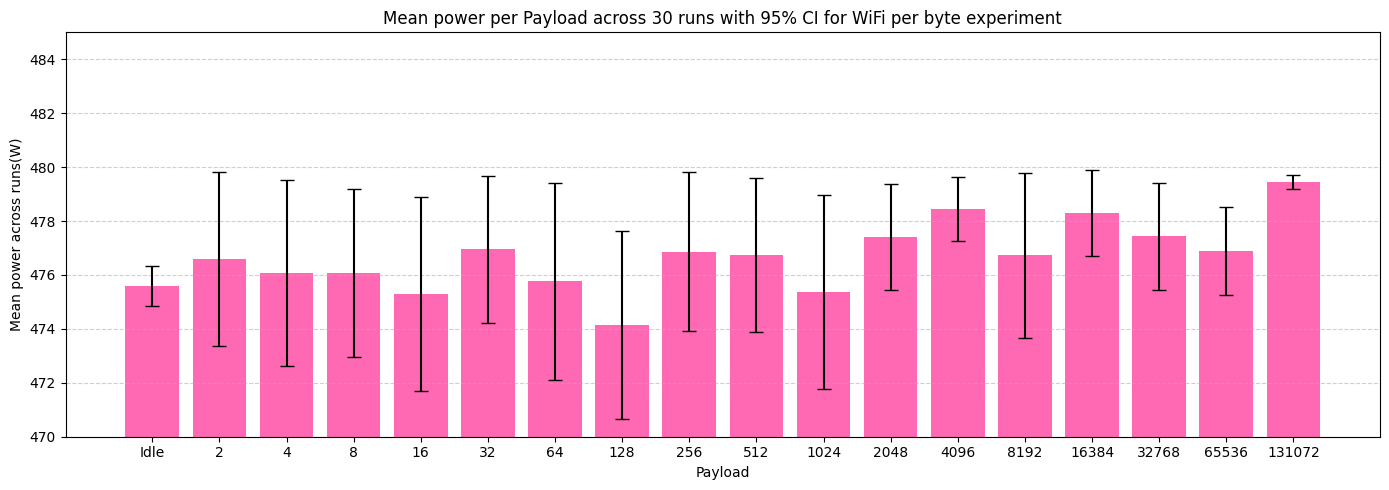

In [31]:
df = across_runs_stats.copy()

# Replace 0 with "Idle"
df["payload_label"] = df["payload_size"].astype(str)
df.loc[df["payload_size"] == 0, "payload_label"] = "Idle"

plt.figure(figsize=(14,5))

plt.bar(
    df["payload_label"],
    df["mean_power"],
    yerr=df["ci95"],
    capsize=5,
    color='hotpink'
)
#cut off y axis at 0.5
plt.ylim(470, 485)
plt.xlabel("Payload")
plt.ylabel("Mean power across runs(W)")
plt.title("Mean power per Payload across 30 runs with 95% CI for WiFi per byte experiment")

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

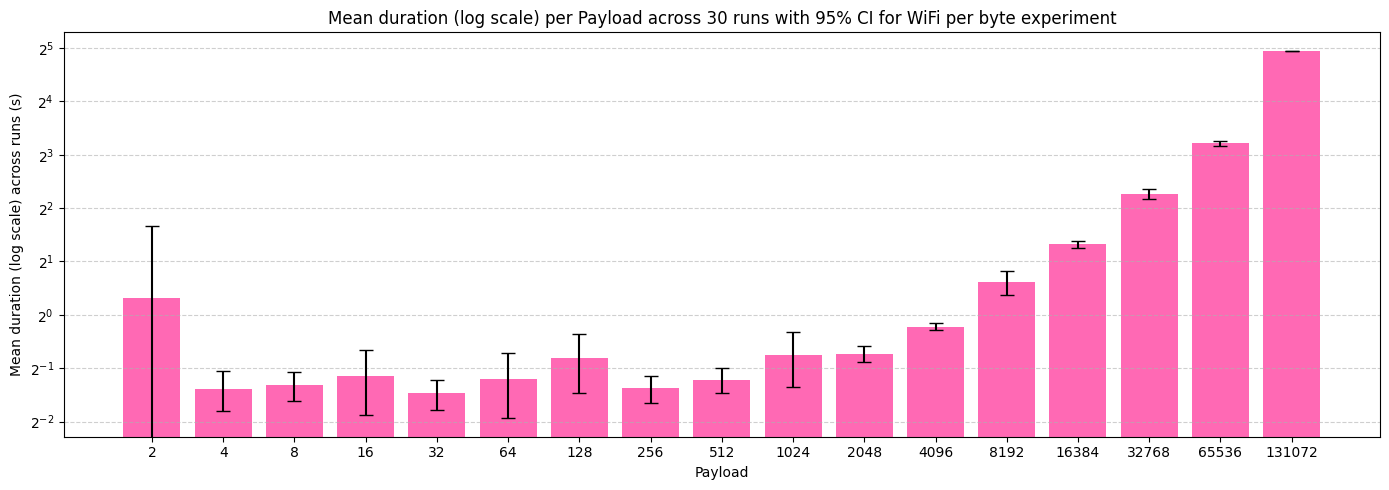

In [32]:
#exclude idle cause way l9nger and irrelevant duration
df = df[df["payload_size"] != 0]

fig, ax = plt.subplots(figsize=(14,5))

ax.bar(
    df["payload_label"],
    df["mean_duration"],
    yerr=df["ci95_duration"],
    capsize=5,
    color='hotpink'
)

#needs to be log scale to show the difference between 1 byte and 1000 bytes, otherwise the 1 byte bar is invisible
ax.set_yscale('log', base=2)

ax.set_xlabel("Payload")
ax.set_ylabel("Mean duration (log scale) across runs (s)")
ax.set_title("Mean duration (log scale) per Payload across 30 runs with 95% CI for WiFi per byte experiment")

ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Energy

in joules per run per payload

In [33]:
print(meter_df)

                     timestamp   v_shunt     phase  run  payload_size     t_s  \
0      2026-03-26 20:30:58.078  115.0735  baseline    1             0  -5.007   
1      2026-03-26 20:30:58.088  115.0735  baseline    1             0  -4.997   
2      2026-03-26 20:30:58.091  107.8088  baseline    1             0  -4.994   
3      2026-03-26 20:30:58.094  107.8088  baseline    1             0  -4.991   
4      2026-03-26 20:30:58.097  107.8088  baseline    1             0  -4.988   
...                        ...       ...       ...  ...           ...     ...   
636146 2026-03-26 21:10:56.621  107.9484      idle   30             0  32.586   
636147 2026-03-26 21:10:56.624  107.9484      idle   30             0  32.589   
636148 2026-03-26 21:10:56.628  107.9484      idle   30             0  32.593   
636149 2026-03-26 21:10:56.631  107.9484      idle   30             0  32.596   
636150 2026-03-26 21:10:56.634  107.9484      idle   30             0  32.599   

         current_A     powe

In [34]:
def energy_with_unc(df):
    df = df.sort_values("t_s")   #make sure data is ordered by time
    # Time differences between samples (Δt)
    dt = df["t_s"].diff().fillna(0) #dt is time difference btw samples within a run and payload size group 

    # Energy: sum of P * Δt
    energy = (df["power_W"] * dt).sum()

    # Uncertainty propagation: sqrt(sum((Δt * u_P)^2))
    energy_unc = np.sqrt(((dt * df["power_unc"])**2).sum()) #we assume time uncertainty (from measurements) is negligeable

    return pd.Series({
        "energy_J": energy,
        "energy_unc": energy_unc
    })


energy_per_run = (
    meter_df[meter_df["payload_size"] != 0]   #remove idle and baseline
    .groupby(["run", "payload_size"])       
    .apply(energy_with_unc)                   #compute energy + uncertainty
    .reset_index()                            #clean dataframe
)

/var/folders/y0/ntq2pbh53yb4nxf1rt5x3bxw0000gq/T/ipykernel_41794/3046151491.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(energy_with_unc)                   #compute energy + uncertainty


In [35]:
print(energy_per_run)

     run  payload_size      energy_J  energy_unc
0      1             2     75.280424    0.611725
1      1             4    153.943940    0.927233
2      1             8    106.020663    0.824444
3      1            16    150.286240    0.867300
4      1            32    108.805998    0.789259
..   ...           ...           ...         ...
495   29         32768   2254.901529    3.472737
496   29         65536   4748.417670    5.045314
497   29        131072  14845.105137    9.005073
498   30             1      8.523457    0.181812
499   30             2  14271.521044    8.784151

[500 rows x 4 columns]


In [36]:
energy_stats = (
    energy_per_run[energy_per_run["payload_size"] != 1]
    .groupby("payload_size")
    .agg(
        mean_energy=("energy_J", "mean"),
        std_energy=("energy_J", "std"),
        count_runs=("energy_J", "count"),

        mean_energy_unc=("energy_unc", lambda x: np.sqrt((x**2).sum()) / len(x))
    )
    .assign(
        se_runs=lambda df: df["std_energy"] / np.sqrt(df["count_runs"]),
        total_unc=lambda df: np.sqrt(df["se_runs"]**2 + df["mean_energy_unc"]**2),
        ci95=lambda df: 1.96 * df["total_unc"]
    )
    .reset_index()
)
print(energy_stats)

    payload_size   mean_energy   std_energy  count_runs  mean_energy_unc  \
0              2    588.705899  2585.869922          30         0.325136   
1              4    180.172730   119.263289          29         0.181535   
2              8    190.266010    93.511117          29         0.187310   
3             16    210.469177   216.249186          29         0.196408   
4             32    170.408623    84.766455          29         0.177839   
5             64    201.943892   206.584923          29         0.194752   
6            128    270.503075   274.332241          29         0.224293   
7            256    183.284226    83.302440          29         0.184373   
8            512    204.425348    82.546324          29         0.194257   
9           1024    278.535576   244.228453          29         0.225511   
10          2048    286.218418    77.686391          29         0.231171   
11          4096    409.855110    51.960317          29         0.276791   
12          

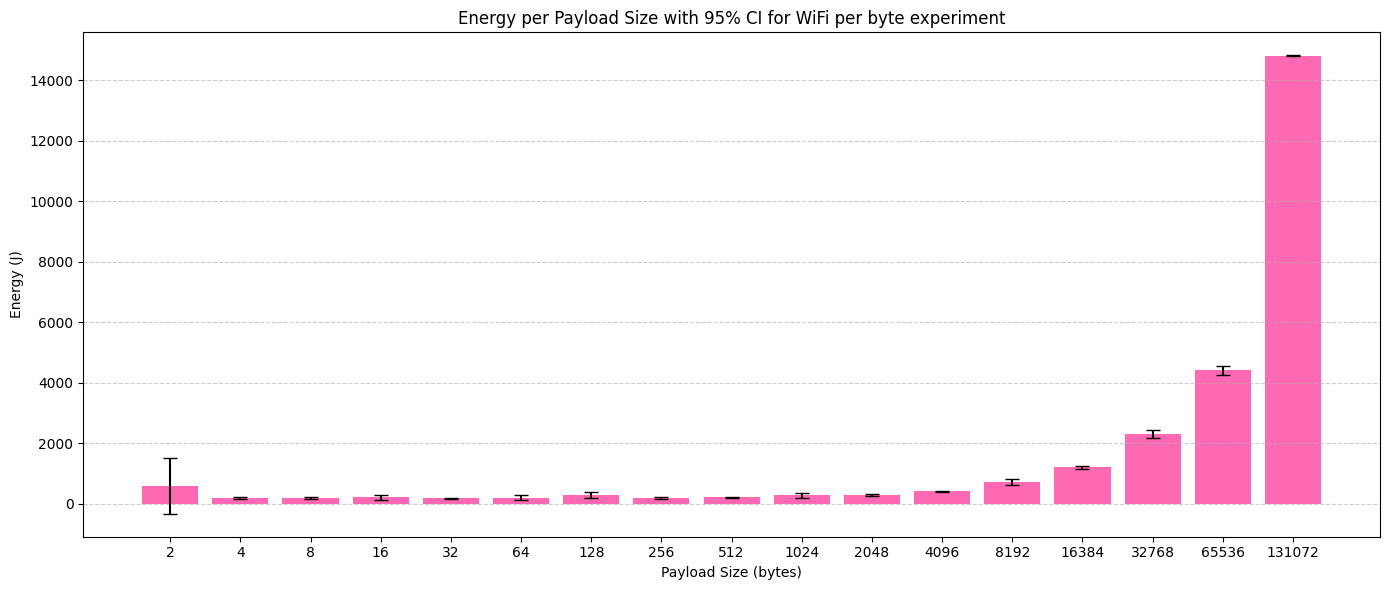

In [37]:
plt.figure(figsize=(14, 6))
plt.bar(
    energy_stats["payload_size"].astype(str),
    energy_stats["mean_energy"],
    yerr=energy_stats["ci95"],
    capsize=5,
    color='hotpink'
)
plt.xlabel("Payload Size (bytes)")
plt.ylabel("Energy (J)")
plt.title("Energy per Payload Size with 95% CI for WiFi per byte experiment")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [38]:
print(energy_stats[["payload_size", "mean_energy"]])

    payload_size   mean_energy
0              2    588.705899
1              4    180.172730
2              8    190.266010
3             16    210.469177
4             32    170.408623
5             64    201.943892
6            128    270.503075
7            256    183.284226
8            512    204.425348
9           1024    278.535576
10          2048    286.218418
11          4096    409.855110
12          8192    727.631089
13         16384   1195.871890
14         32768   2288.427914
15         65536   4414.363769
16        131072  14816.891710


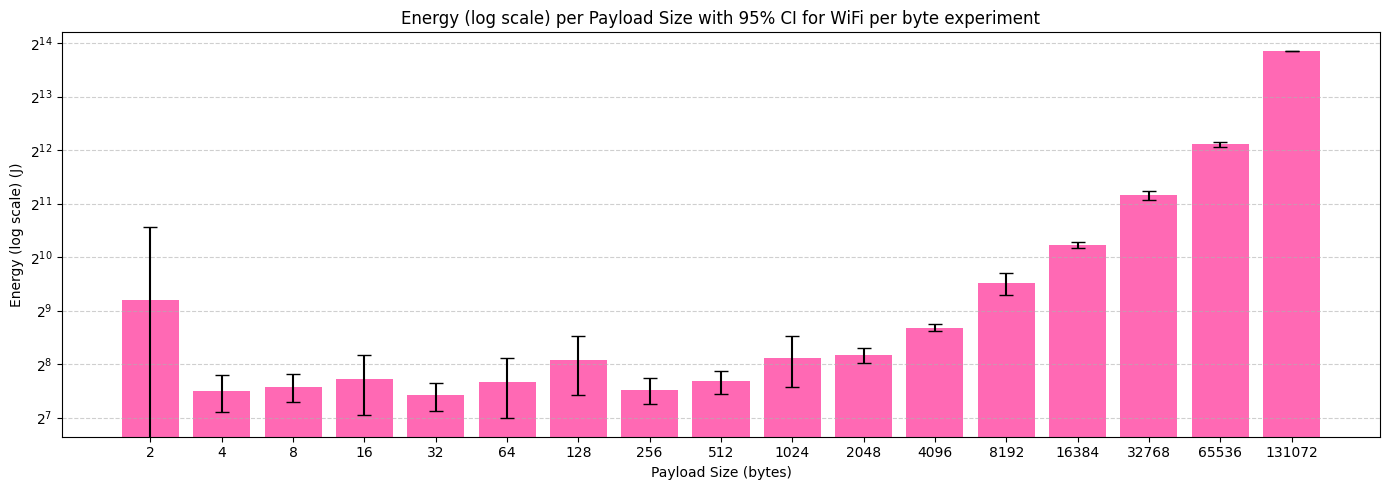

In [39]:
fig, ax = plt.subplots(figsize=(14,5))
ax.bar(
    energy_stats["payload_size"].astype(str),
    energy_stats["mean_energy"],
    yerr=energy_stats["ci95"],
    capsize=5,
    color='hotpink'
)
#gotta log scale it
ax.set_yscale('log', base=2)

ax.set_xlabel("Payload Size (bytes)")
ax.set_ylabel("Energy (log scale) (J)")
ax.set_title("Energy (log scale) per Payload Size with 95% CI for WiFi per byte experiment")
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Old stats without power

## Stats about voltage
nothing about power yet cause i dont know shunt resistance

In [40]:
voltage_df = voltage_df[voltage_df["payload_size"] != 1]
summary_V_shunt = (
    voltage_df
    .groupby("payload_size")["v_shunt"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
summary_V_shunt["sem"] = summary_V_shunt["std"] / np.sqrt(summary_V_shunt["count"])  # standard error
summary_V_shunt["ci95"] = 1.96 * summary_V_shunt["sem"]  # 95% confidence interval

print(summary_V_shunt)

    payload_size        mean       std   count       sem      ci95
0              0  107.570235  2.740156  189905  0.006288  0.012324
1              2  107.044658  3.699821   10250  0.036544  0.071627
2              4  106.136595  4.294087    3091  0.077236  0.151383
3              8  106.608050  4.022364    3236  0.070709  0.138590
4             16  105.235796  4.901371    3629  0.081362  0.159470
5             32  106.937679  3.572879    2876  0.066623  0.130581
6             64  105.188072  5.073368    3440  0.086500  0.169540
7            128  106.568063  4.651421    4612  0.068492  0.134245
8            256  106.957253  3.614985    3122  0.064698  0.126808
9            512  106.935453  3.567218    3454  0.060697  0.118966
10          1024  105.446141  4.818923    4810  0.069483  0.136186
11          2048  107.485284  2.557893    4842  0.036760  0.072049
12          4096  107.959233  1.737457    6871  0.020961  0.041083
13          8192  106.841358  3.868160   12344  0.034816  0.06

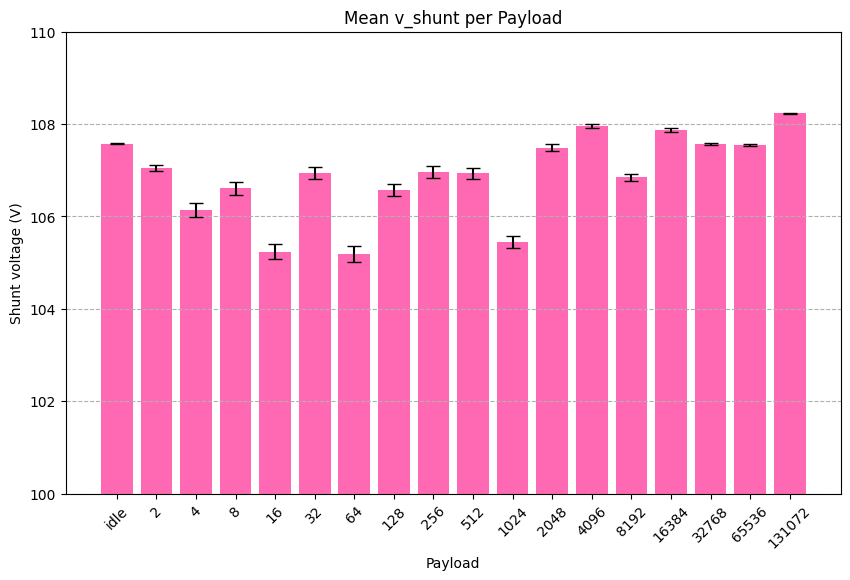

In [44]:
summary_V_shunt["payload_label"] = summary_V_shunt["payload_size"].astype(str)
summary_V_shunt.loc[summary_V_shunt["payload_size"] == 0, "payload_label"] = "idle"

plt.figure(figsize=(10, 6))
plt.bar(
    summary_V_shunt["payload_label"],
    summary_V_shunt["mean"],
    yerr=summary_V_shunt["ci95"],
    capsize=5,
    color='hotpink',
)

#cut off y axis at 0.1
plt.ylim(100, 110)
plt.xlabel("Payload")
plt.ylabel("Shunt voltage (V)")
plt.title("Mean v_shunt per Payload")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.show()

same thing but different, i kinda hate this

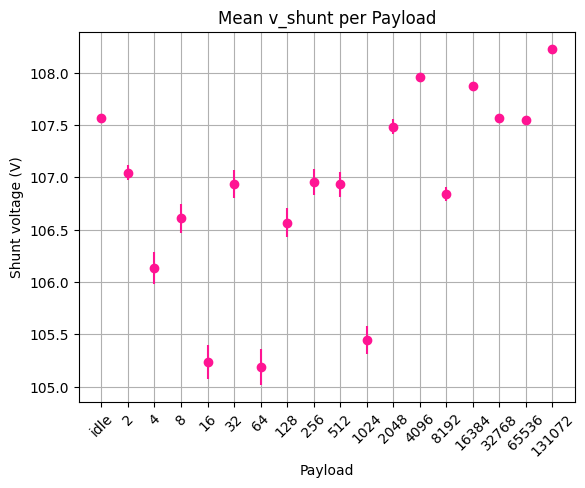

In [45]:
plt.errorbar(
    summary_V_shunt["payload_label"],
    summary_V_shunt["mean"],
    yerr=summary_V_shunt["ci95"],
    fmt='o',
    color= 'deeppink'
)

plt.xlabel("Payload")
plt.ylabel("Shunt voltage (V)")
plt.title("Mean v_shunt per Payload")
plt.xticks(rotation=45)
plt.grid()
plt.show()

wanna see outliers and stuff

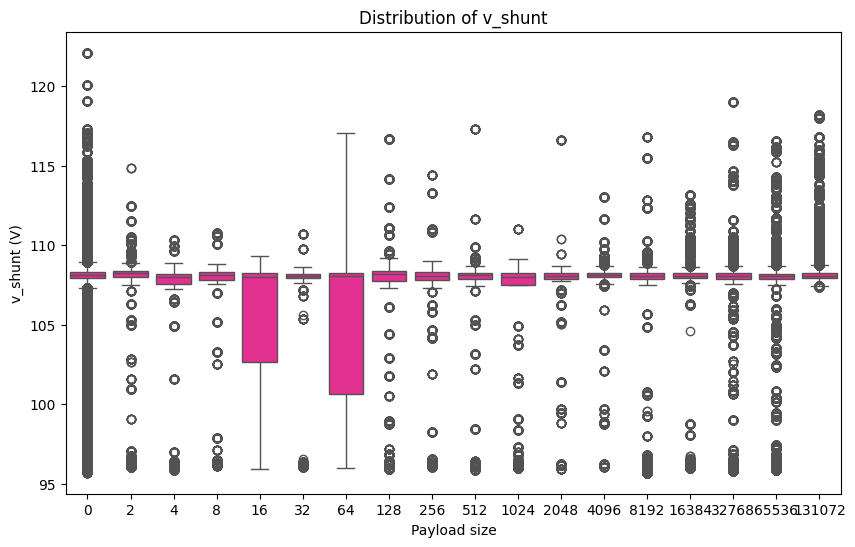

In [46]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=voltage_df,
    x="payload_size",
    y="v_shunt",
    color='deeppink' #why is the color not changing?
)

plt.xlabel("Payload size")
plt.ylabel("v_shunt (V)")
plt.title("Distribution of v_shunt")
plt.show()

## Stats about time

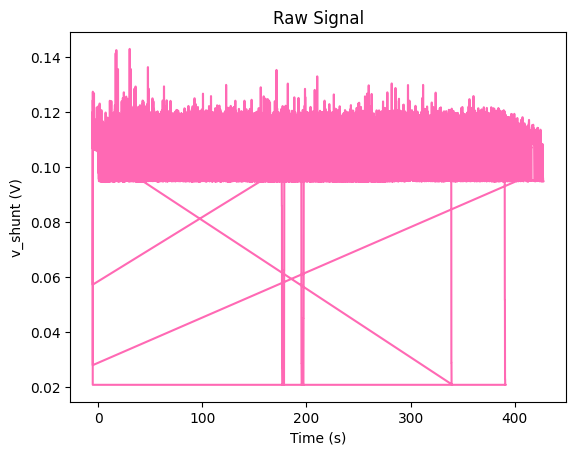

In [111]:
plt.plot(voltage_df["t_s"], voltage_df["v_shunt"], color='hotpink')
plt.xlabel("Time (s)")
plt.ylabel("v_shunt (V)")
plt.title("Raw Signal")
plt.show()

In [ ]:
events_df["duration_s"] = (
    events_df["t_end_s"] - events_df["t_start_s"]
)

tx_summary = (
    events_df
    .groupby("payload_size")["duration_s"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
tx_summary["sem"] = tx_summary["std"] / np.sqrt(tx_summary["count"])  # standard error
tx_summary["ci95"] = 1.96 * tx_summary["sem"]  #95% confidence interval
print(tx_summary)

   payload_size       mean       std  count       sem      ci95
0             1   0.599062  0.067459     16  0.016865  0.033055
1          1024   1.811875  0.047165     16  0.011791  0.023111
2           128   1.716625  0.049628     16  0.012407  0.024318
3            16   1.687625  0.092863     16  0.023216  0.045503
4         16384   3.777188  0.130683     16  0.032671  0.064035
5             2   1.726562  0.173704     16  0.043426  0.085115
6          2048   1.974875  0.085262     16  0.021315  0.041778
7           256   1.714688  0.050624     16  0.012656  0.024806
8            32   1.695562  0.045910     16  0.011478  0.022496
9         32768   5.808125  0.101231     16  0.025308  0.049603
10            4   1.703875  0.163992     16  0.040998  0.080356
11         4096   2.194125  0.083696     16  0.020924  0.041011
12          512   1.796875  0.062177     16  0.015544  0.030467
13           64   1.758750  0.057245     16  0.014311  0.028050
14        65536  10.016875  0.230474    

In [ ]:
tx_summary["payload_size"] = tx_summary["payload_size"].astype(str)
#please order omg
plt.figure()
plt.bar(
    tx_summary["payload_size"].astype(str),
    tx_summary["mean"],
    yerr=tx_summary["ci95"],
    color='hotpink'
)
plt.loc = sorted(events_df["payload_size"].unique())
plt.xlabel("Payload size")
plt.ylabel("TX duration (s)")
plt.title("Transmission Time vs Payload Size")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

NameError: name 'tx_summary' is not defined